<a href="https://colab.research.google.com/github/SSClements/INDE2000-Project/blob/main/INDE2000_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Library used**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

# **Import Data**

In [2]:
file_names = [
    '2010-2011 Solar home electricity data.csv',
    '2011-2012 Solar home electricity data v2.csv',
    '2012-2013 Solar home electricity data v2.csv'
]

all_years_list = []

for name in file_names:

    try:
        # header=1 to skip the PDF description row
        temp_df = pd.read_csv(name, header=1)

        # Clean column names just in case
        temp_df.columns = [str(col).strip().lower() for col in temp_df.columns]

        # Find 'Date' and 'Category' by position or keyword
        date_col = next((c for c in temp_df.columns if 'date' in c), None)
        cat_col = next((c for c in temp_df.columns if 'consumption' in c or 'category' in c), None)

        if not date_col or not cat_col:
            print(f"Skipping {name}: Missing Date/Category columns.")
            continue

        # Select 48 columns by position (The last 48 columns)
        # In Ausgrid files, the 48 half-hour slots are always the last 48 columns.
        # Take the last 48 columns and rename them to 1-48 for consistency.
        power_data_cols = temp_df.columns[-48:].tolist()

        # Filter for General Consumption (GC)
        temp_gc = temp_df[temp_df[cat_col].astype(str).str.contains('GC', case=False, na=False)].copy()

        # Ensure data is numeric
        for col in power_data_cols:
            temp_gc[col] = pd.to_numeric(temp_gc[col], errors='coerce')

        # Aggregate: Mean of ALL customers
        daily_avg = temp_gc.groupby(date_col)[power_data_cols].mean().reset_index()

        # Rename columns to standard: 'Date', '1', '2', ..., '48'
        standard_names = ['Date'] + [str(i) for i in range(1, 49)]
        daily_avg.columns = standard_names

        all_years_list.append(daily_avg)
        print(f"SUCCESS: Processed {name} with 48 time slots.")

        del temp_df, temp_gc

    except Exception as e:
        print(f"Error at {name}: {e}")


SUCCESS: Processed 2010-2011 Solar home electricity data.csv with 48 time slots.
SUCCESS: Processed 2011-2012 Solar home electricity data v2.csv with 48 time slots.
SUCCESS: Processed 2012-2013 Solar home electricity data v2.csv with 48 time slots.


# **Transformation, Deseasonalization and Visualization**

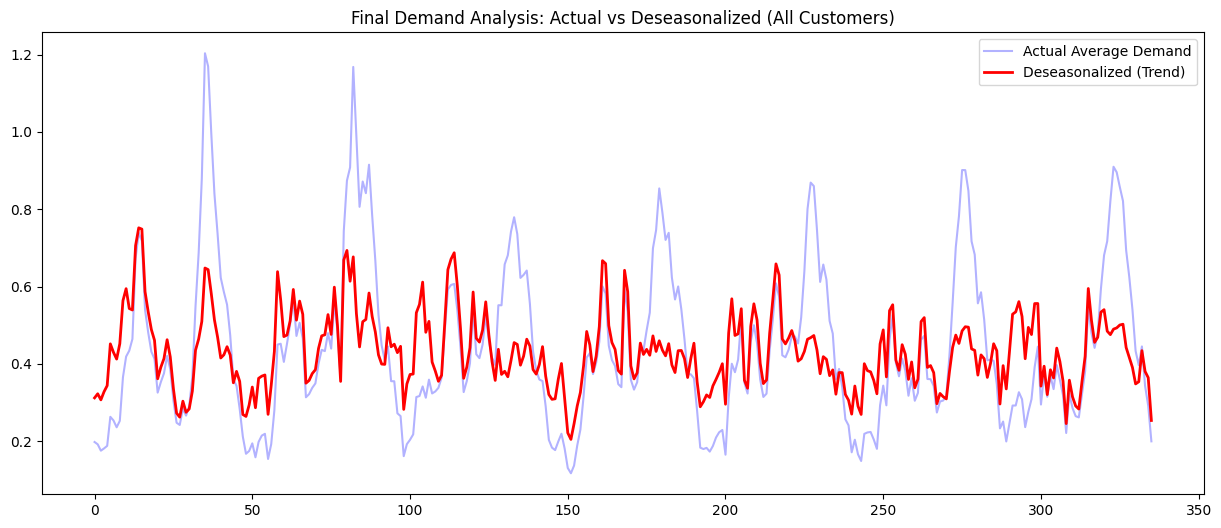

In [3]:
if all_years_list:
    df_combined = pd.concat(all_years_list, ignore_index=True)

    # Transformation
    time_periods = [str(i) for i in range(1, 49)]
    df_long = df_combined.melt(id_vars=['Date'], value_vars=time_periods,
                               var_name='Period', value_name='Avg_kWh')

    df_long['Date'] = pd.to_datetime(df_long['Date'], dayfirst=True)
    df_long['Period'] = df_long['Period'].astype(int)
    df_long = df_long.sort_values(['Date', 'Period']).reset_index(drop=True)

    # Deseasonalization (Lecture 6)
    grand_mean = df_long['Avg_kWh'].mean()
    seasonal_indices = df_long.groupby('Period')['Avg_kWh'].mean() / grand_mean
    df_long['Seasonal_Index'] = df_long['Period'].map(seasonal_indices)
    df_long['Deseasonalized_kWh'] = df_long['Avg_kWh'] / df_long['Seasonal_Index']

    # Visualization
    plt.figure(figsize=(15, 6))
    plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='blue', alpha=0.3)
    plt.plot(df_long['Deseasonalized_kWh'][:336], label='Deseasonalized (Trend)', color='red', linewidth=2)
    plt.title('Final Demand Analysis: Actual vs Deseasonalized (All Customers)')
    plt.legend()
    plt.show()
else:
    print("Check if your files are actually .csv and have 48 data columns at the end.")

In [4]:
# Counting NA values for total data
na_count = df_long['Avg_kWh'].isna().sum()
total_count = len(df_long)
na_pct = (na_count / total_count) * 100
print(f"Missing values (NA): {na_count} out of {total_count} ({na_pct:.2f}%)")

# Document Data
## Total Entries, Missing Data, Percentage
for i, df in enumerate(all_years_list):
    year_label = file_names[i].split('/')[-1][:9]

    non_missing = df.iloc[:, 1:].count().sum()
    total_cells = df.iloc[:, 1:].size
    missing = total_cells - non_missing
    missing_pct = (missing / total_cells) * 100

    print(f"  {year_label} | Total: {total_cells} | Missing: {missing} | ({missing_pct:.2f}%)")


Missing values (NA): 731 out of 52608 (1.39%)
  2010-2011 | Total: 17520 | Missing: 0 | (0.00%)
  2011-2012 | Total: 17568 | Missing: 366 | (2.08%)
  2012-2013 | Total: 17520 | Missing: 365 | (2.08%)


In [5]:
# Outliers
mean_val = df_long['Deseasonalized_kWh'].mean()
std_val = df_long['Deseasonalized_kWh'].std()
outliers = df_long[(df_long['Deseasonalized_kWh'] < mean_val - 3*std_val) |
                   (df_long['Deseasonalized_kWh'] > mean_val + 3*std_val)]

total_count = len(df_long)
print(f"Outliers (±3 std): {len(outliers)} out of {total_count} ({(len(outliers)/total_count)*100:.2f}%)")



Outliers (±3 std): 702 out of 52608 (1.33%)


In [6]:
print(outliers[['Date', 'Period', 'Avg_kWh', 'Deseasonalized_kWh']].sort_values('Deseasonalized_kWh', ascending=False).head(20))

            Date  Period   Avg_kWh  Deseasonalized_kWh
10540 2011-02-05      29  1.502655            1.606522
10541 2011-02-05      30  1.529517            1.578819
10542 2011-02-05      31  1.559138            1.521106
10538 2011-02-05      27  1.335966            1.469439
10539 2011-02-05      28  1.349586            1.461894
10536 2011-02-05      25  1.317897            1.426951
10535 2011-02-05      24  1.297724            1.426731
10543 2011-02-05      32  1.580828            1.421622
10537 2011-02-05      26  1.268172            1.392051
10534 2011-02-05      23  1.174586            1.293534
10544 2011-02-05      33  1.608069            1.275987
10584 2011-02-06      25  1.144759            1.239486
10583 2011-02-06      24  1.094793            1.203627
44285 2013-01-08      30  1.163971            1.201489
10582 2011-02-06      23  1.067724            1.175850
44284 2013-01-08      29  1.058324            1.131477
10585 2011-02-06      26  1.025828            1.126033
44286 2013

Outliers are during peak summer season, keep them in

# Model Formulation

hi these models are currently just using all three years to be created and then plotting their predictions of those same three years. I have not done a train/test split ratio to test accuracy of forecasting future data


also please let me know if it looks wrong or you think we should approach differently


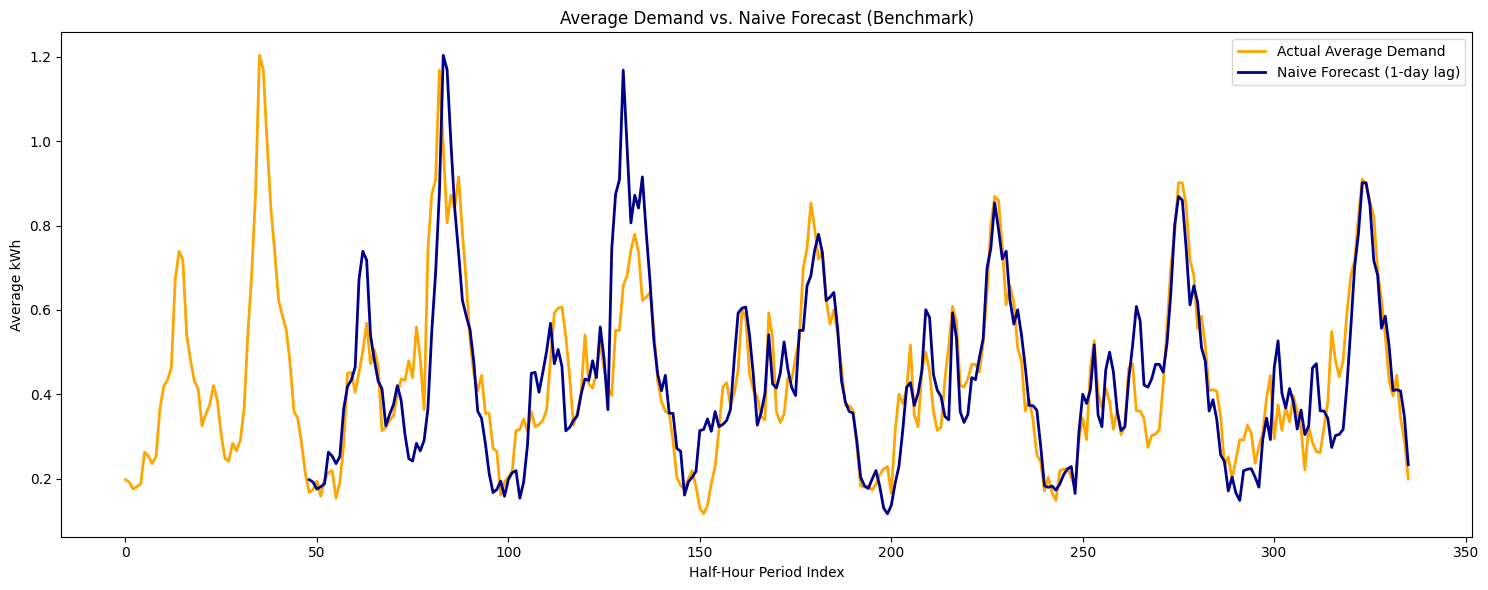

In [7]:
# Naive Forecast

# Shift by 48 periods (one full day of 30-min intervals)
df_long['Naive_Deseasonalized'] = df_long['Deseasonalized_kWh'].shift(48)

# Re-seasonalize
df_long['Naive'] = df_long['Naive_Deseasonalized'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='orange', linewidth=2)
plt.plot(df_long['Naive'][:336], label='Naive Forecast (1-day lag)', color='darkblue', linewidth=2)
plt.title('Average Demand vs. Naive Forecast (Benchmark)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

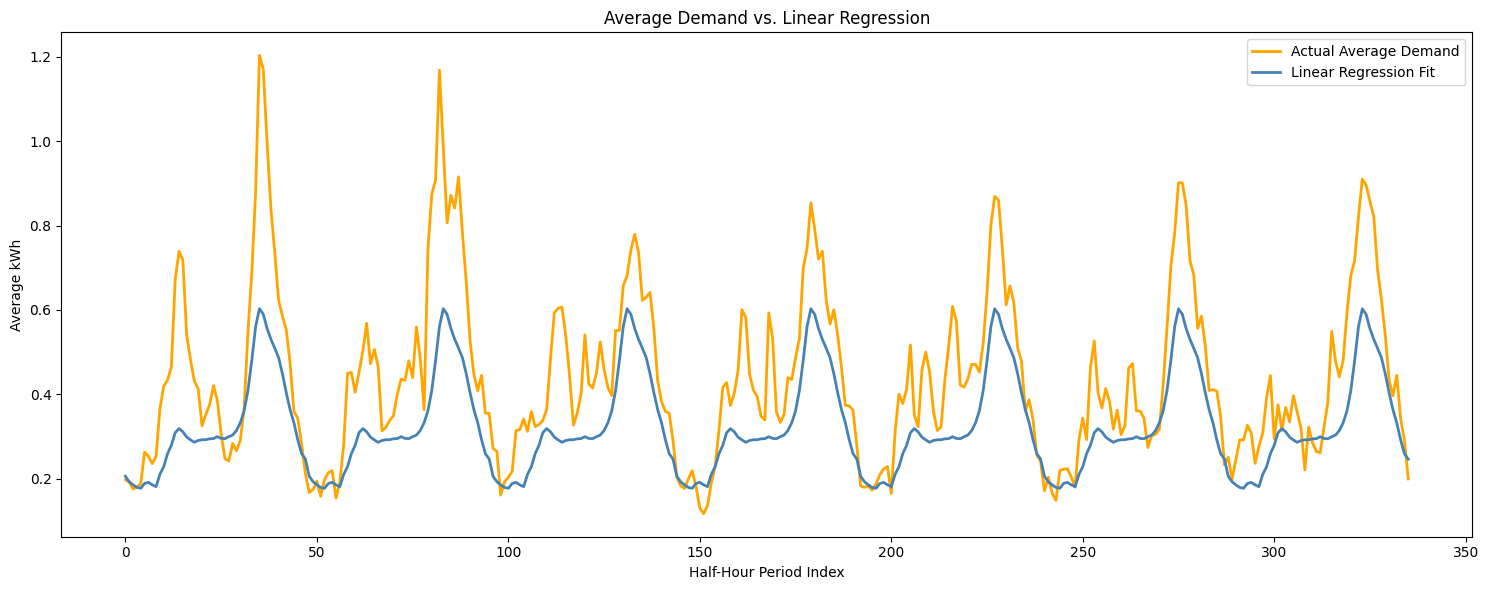

In [8]:
# Linear Regression

# Drop NaNs and reset index so X and y align
mask = df_long['Deseasonalized_kWh'].notna()
y = df_long.loc[mask, 'Deseasonalized_kWh'].astype(float).reset_index(drop=True)

t_vals = np.arange(mask.sum())
period_dummies = pd.get_dummies(df_long.loc[mask, 'Period'], prefix='P', drop_first=True).astype(float).reset_index(drop=True)

X = pd.concat([pd.Series(t_vals, name='t'), period_dummies], axis=1)
X = sm.add_constant(X)

model_lr = sm.OLS(y, X).fit()

# Store fitted values and re-seasonalize

df_long['LR_Deseasonalized'] = model_lr.fittedvalues
df_long['LR'] = df_long['LR_Deseasonalized'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='orange', linewidth=2)
plt.plot(df_long['LR'][:336], label='Linear Regression Fit', color='steelblue', linewidth=2)
plt.title('Average Demand vs. Linear Regression')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

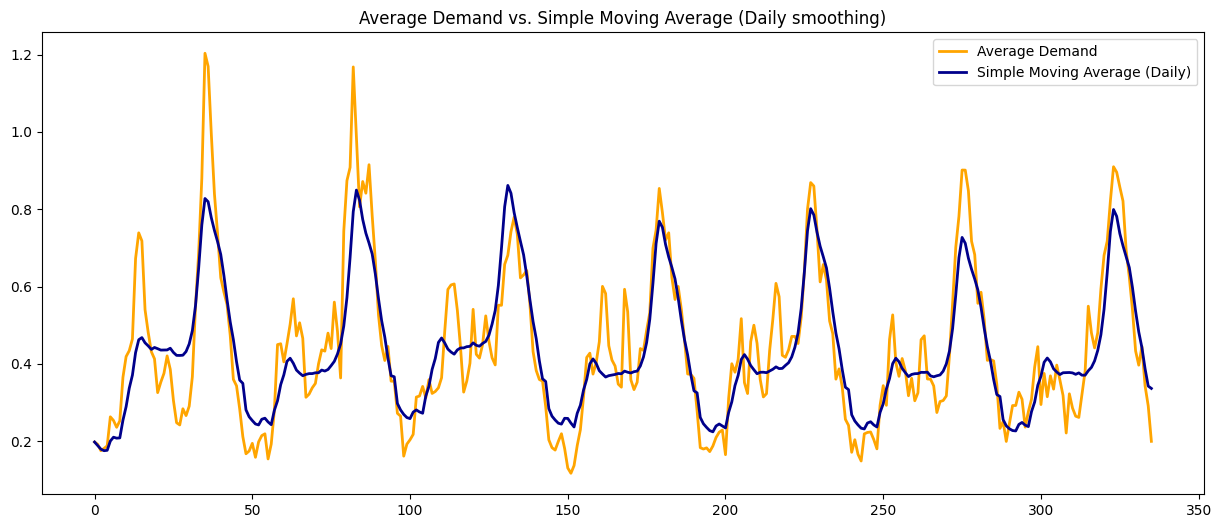

In [9]:
# Simple Moving Average

## One day smoothing (30 min intervals)
df_long['SMA_48_Deseasonalized'] = df_long.Deseasonalized_kWh.rolling(48, min_periods=1).mean()

## Re-seasonalisation
df_long['SMA_48'] = df_long['SMA_48_Deseasonalized'] * df_long['Seasonal_Index']

# Simple Moving Average Plot

plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['SMA_48'][:336], label='Simple Moving Average (Daily)', color='darkblue', linewidth=2)
plt.title('Average Demand vs. Simple Moving Average (Daily smoothing)')
plt.legend()
plt.show()

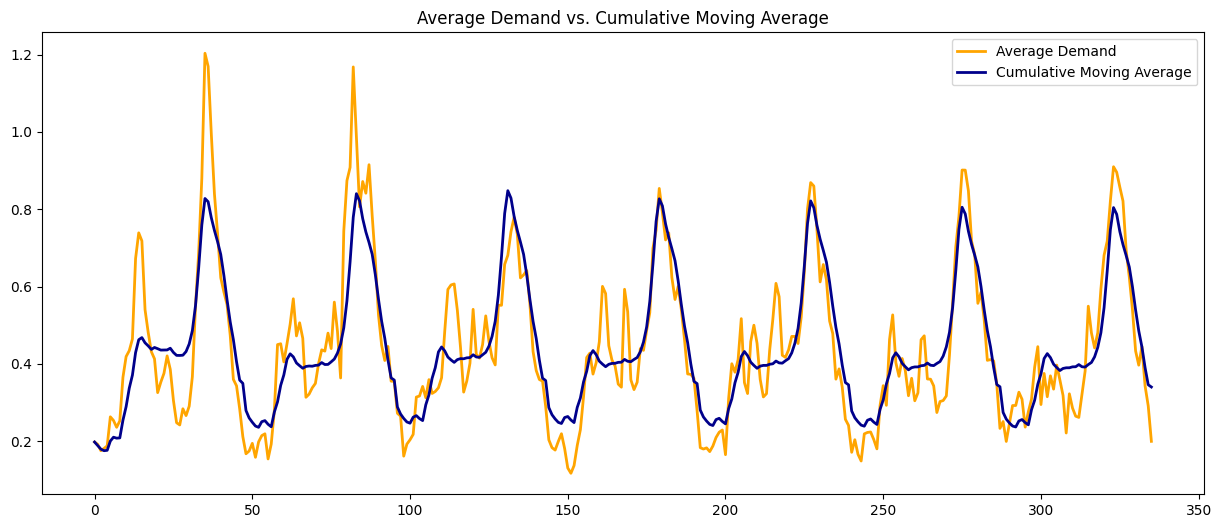

In [10]:
# Cumulative Moving Average

df_long['CMA_Deseasonalized'] = df_long.Deseasonalized_kWh.expanding().mean()

## Re-seasonalisation
df_long['CMA'] = df_long['CMA_Deseasonalized'] * df_long['Seasonal_Index']


plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['CMA'][:336], label='Cumulative Moving Average', color='darkblue', linewidth=2)
plt.title('Average Demand vs. Cumulative Moving Average')
plt.legend()
plt.show()

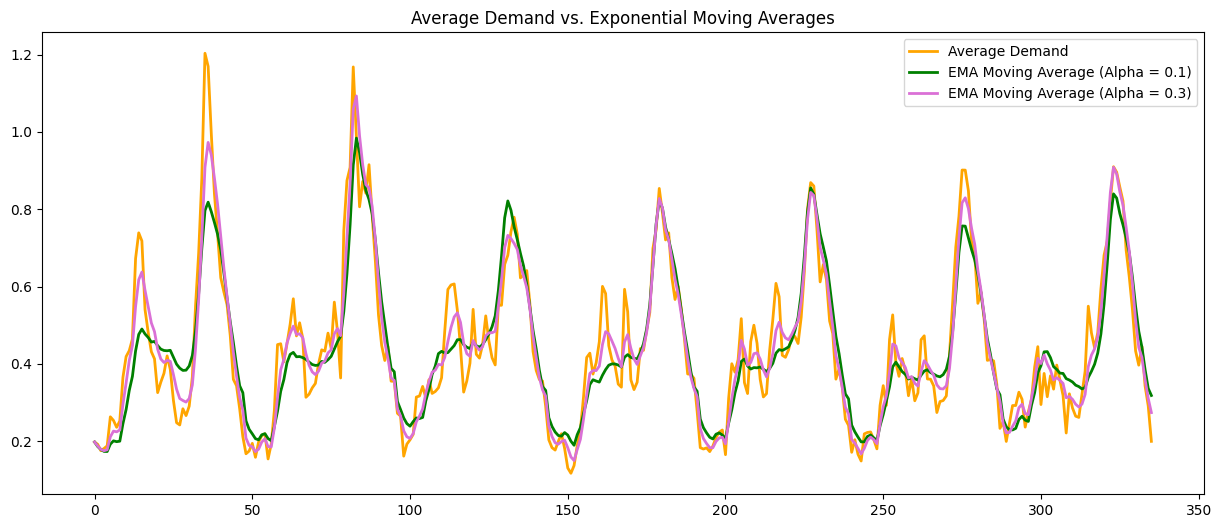

In [11]:
# Exponential Moving Average

df_long['EMA_0.1_Deseasonalized'] = df_long.Deseasonalized_kWh.ewm(alpha=0.1, adjust = False).mean()
df_long['EMA_0.3_Deseasonalized'] = df_long.Deseasonalized_kWh.ewm(alpha=0.3, adjust = False).mean()

## Re-seasonalisation
df_long['EMA_0.1'] = df_long['EMA_0.1_Deseasonalized'] * df_long['Seasonal_Index']
df_long['EMA_0.3'] = df_long['EMA_0.3_Deseasonalized'] * df_long['Seasonal_Index']


plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['EMA_0.1'][:336], label='EMA Moving Average (Alpha = 0.1)', color='green', linewidth=2)
plt.plot(df_long['EMA_0.3'][:336], label='EMA Moving Average (Alpha = 0.3)', color='orchid', linewidth=2)
plt.title('Average Demand vs. Exponential Moving Averages')
plt.legend()
plt.show()

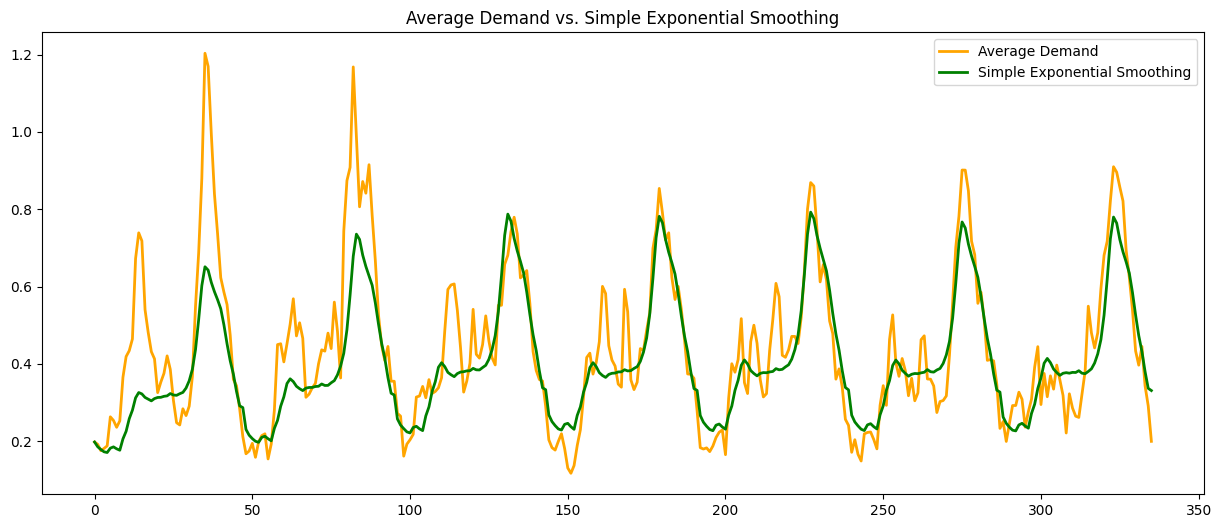

In [12]:
# Simple Exponential Smoothing

m = 48   # daily
alpha = 1/(2*m)
alpha

df_long['SES_Deseasonalised'] = SimpleExpSmoothing(df_long['Deseasonalized_kWh']).fit(smoothing_level=alpha,optimized=False,use_brute=True).fittedvalues

## Reseasonalized
df_long['SES'] = df_long['SES_Deseasonalised'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['SES'][:336], label='Simple Exponential Smoothing', color='green', linewidth=2)
plt.title('Average Demand vs. Simple Exponential Smoothing')
plt.legend()
plt.show()

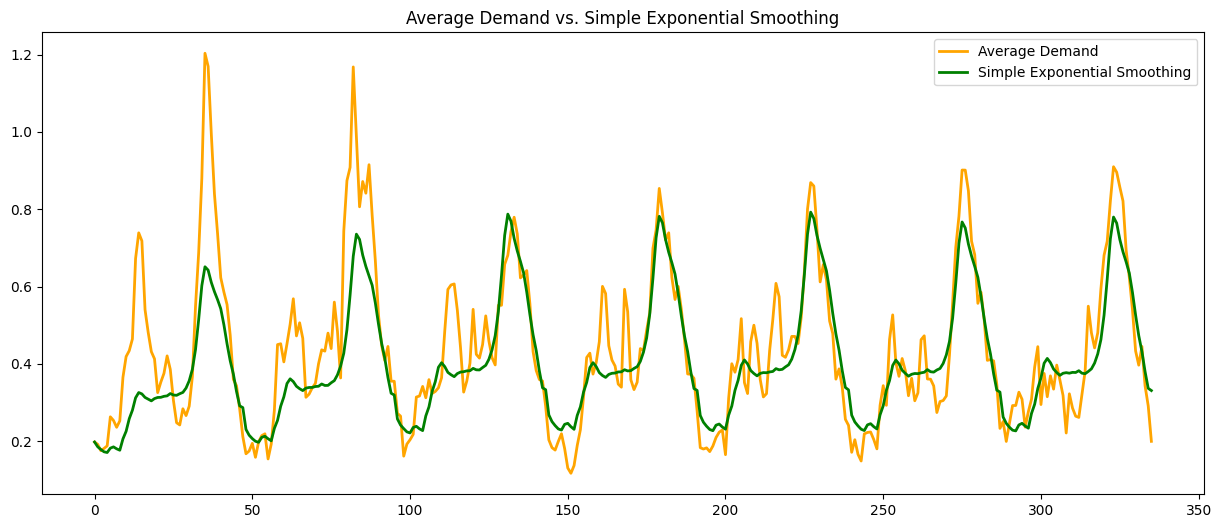

In [13]:
# Simple Exponential Smoothing (Single HWES)

m = 48   # daily
alpha = 1/(2*m)
alpha

df_long['SES_Deseasonalised'] = SimpleExpSmoothing(df_long['Deseasonalized_kWh']).fit(smoothing_level=alpha,optimized=False,use_brute=True).fittedvalues

## Reseasonalized
df_long['SES'] = df_long['SES_Deseasonalised'] * df_long['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['SES'][:336], label='Simple Exponential Smoothing', color='green', linewidth=2)
plt.title('Average Demand vs. Simple Exponential Smoothing')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


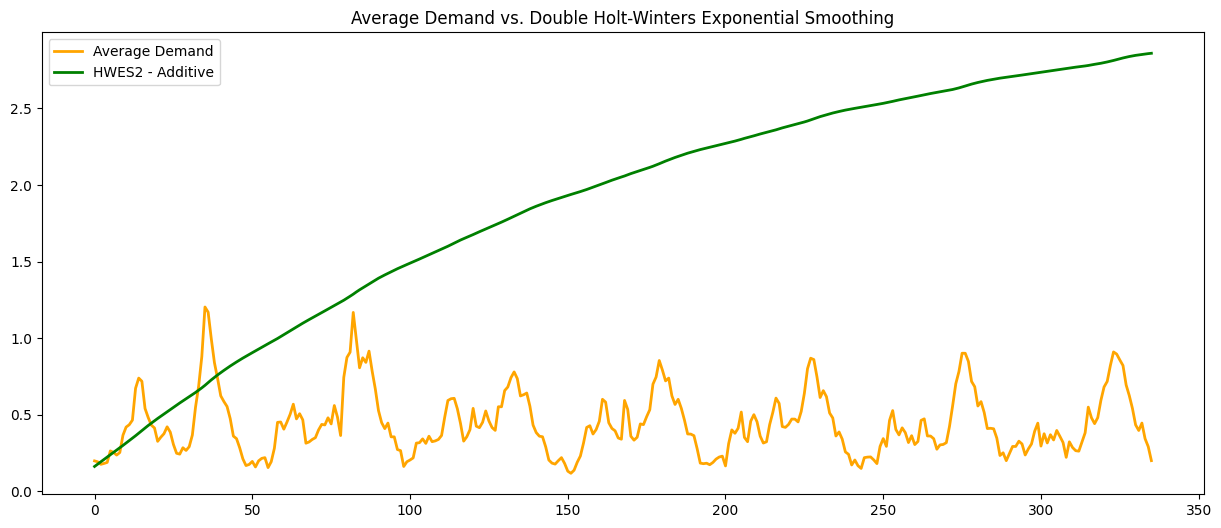

In [14]:
# Double Holt-Winters Exponential Smoothing

df_long['HWES2_ADD'] = ExponentialSmoothing(df_long['Avg_kWh'], trend = 'add').fit().fittedvalues

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['HWES2_ADD'][:336], label='HWES2 - Additive', color='green', linewidth=2)
plt.title('Average Demand vs. Double Holt-Winters Exponential Smoothing')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


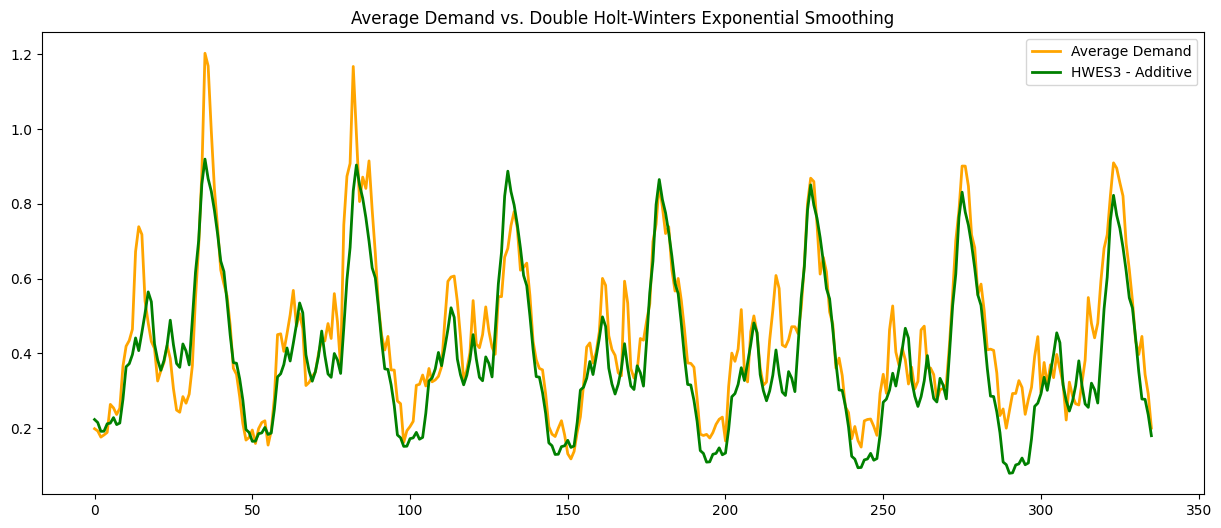

In [15]:
# Triple Holt-Winters Exponential Smoothing
df_long['HWES3_ADD'] = ExponentialSmoothing(df_long['Avg_kWh'], trend = 'add', seasonal='add', seasonal_periods = 48).fit().fittedvalues

# Plot
plt.figure(figsize=(15, 6))
plt.plot(df_long['Avg_kWh'][:336], label='Average Demand', color='orange', linewidth=2)
plt.plot(df_long['HWES3_ADD'][:336], label='HWES3 - Additive', color='green', linewidth=2)
plt.title('Average Demand vs. Double Holt-Winters Exponential Smoothing')
plt.legend()
plt.show()

In [16]:
zero_rows = df_long[df_long['Avg_kWh'] == 0]
print(zero_rows[['Date', 'Period', 'Avg_kWh']])

            Date  Period  Avg_kWh
4516  2010-10-03       5      0.0
4517  2010-10-03       6      0.0
21987 2011-10-02       4      0.0
21988 2011-10-02       5      0.0
39795 2012-10-07       4      0.0
39796 2012-10-07       5      0.0


# **Split Ratio: 1st & 2nd Years Train / 3rd Year Test**

In [20]:
# ── Train / Test Split ───────────────────────────────────────────
# Train: Year 1 & 2  |  Test: Year 3

split_date = pd.Timestamp('2012-07-01')

train = df_long[df_long['Date'] < split_date].copy()
test  = df_long[df_long['Date'] >= split_date].copy()

print(f"Train size: {len(train)} | Date range: {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Test size:  {len(test)}  | Date range: {test['Date'].min().date()} → {test['Date'].max().date()}")

Train size: 35088 | Date range: 2010-07-01 → 2012-06-30
Test size:  17520  | Date range: 2012-07-01 → 2013-06-30


## **Naive**

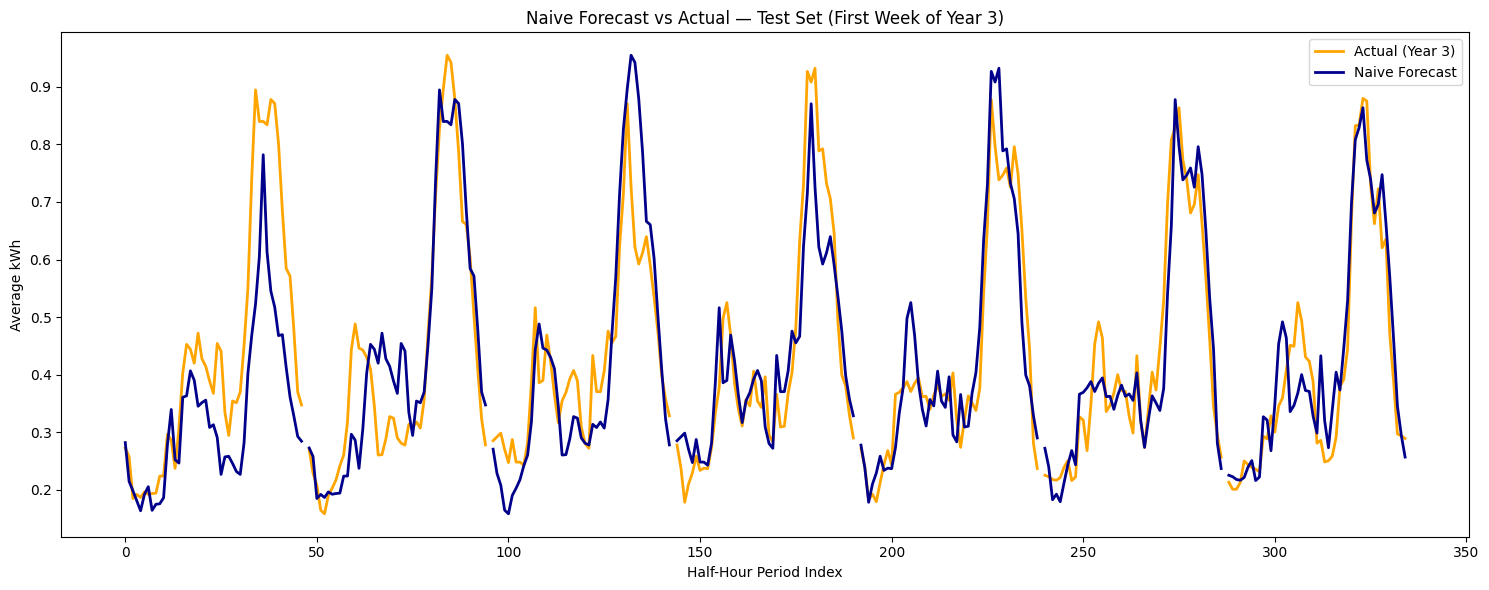

In [21]:
# ── Naive Forecast (Benchmark) ───────────────────────────────────
# Seasonal naive: forecast = same period from 1 day ago (48 step lag)

df_long['Naive_Deseasonalized'] = df_long['Deseasonalized_kWh'].shift(48)
df_long['Naive'] = df_long['Naive_Deseasonalized'] * df_long['Seasonal_Index']

# Pull out test portion
test_naive = df_long[df_long['Date'] >= split_date].copy()

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_naive['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_naive['Naive'].values[:336],   label='Naive Forecast', color='darkblue', linewidth=2)
plt.title('Naive Forecast vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# ── Naive Accuracy (Test Set Only) ───────────────────────────────

test_naive_clean = test_naive.dropna(subset=['Naive', 'Avg_kWh'])
errors_naive = test_naive_clean['Avg_kWh'] - test_naive_clean['Naive']

Bias_naive  = errors_naive.mean()
MAD_naive   = errors_naive.abs().mean()
MAPE_naive  = (errors_naive.abs() / test_naive_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_naive  = np.sqrt((errors_naive ** 2).mean())
TS_naive    = Bias_naive / MAD_naive

print("=== Naive Forecast (Benchmark) — Test Set Accuracy ===")
print(f"  Bias : {Bias_naive:.4f} kWh")
print(f"  MAD  : {MAD_naive:.4f} kWh")
print(f"  MAPE : {MAPE_naive:.2f}%")
print(f"  RMSE : {RMSE_naive:.4f} kWh")
print(f"  TS   : {TS_naive:.4f}")

=== Naive Forecast (Benchmark) — Test Set Accuracy ===
  Bias : 0.0002 kWh
  MAD  : 0.0601 kWh
  MAPE : 19.69%
  RMSE : 0.0976 kWh
  TS   : 0.0039


## **Simple Moving Average**

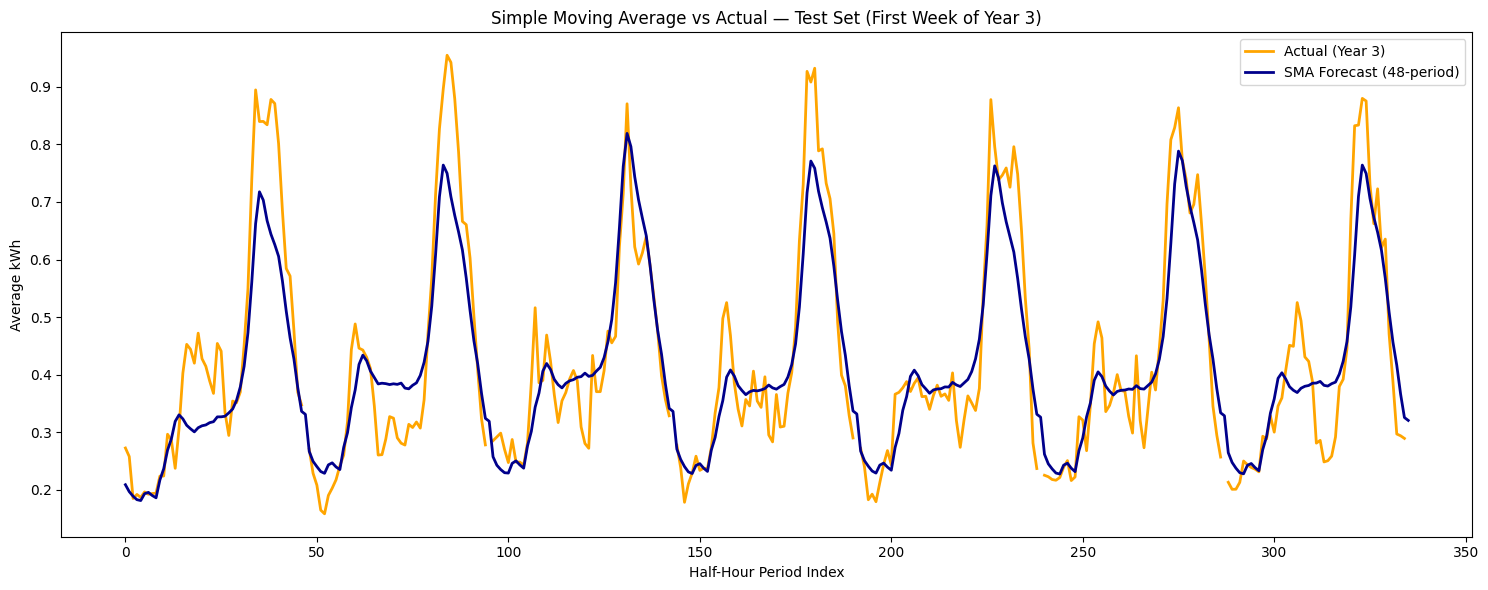

In [51]:
# ── Simple Moving Average (Train/Test Split) ─────────────────────
# Fit on full series (so test gets valid rolling window from train)
# Window = 48 (1 day smoothing)

df_long['SMA_48_Deseasonalized'] = df_long['Deseasonalized_kWh'].rolling(48, min_periods=1).mean()
df_long['SMA_48'] = df_long['SMA_48_Deseasonalized'] * df_long['Seasonal_Index']

# Pull out test portion
test_sma = df_long[df_long['Date'] >= split_date].copy()

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_sma['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_sma['SMA_48'].values[:336],  label='SMA Forecast (48-period)', color='darkblue', linewidth=2)
plt.title('Simple Moving Average vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# ── SMA Accuracy (Test Set Only) ─────────────────────────────────

test_sma_clean = test_sma.dropna(subset=['SMA_48', 'Avg_kWh'])
errors_sma = test_sma_clean['Avg_kWh'] - test_sma_clean['SMA_48']

Bias_sma  = errors_sma.mean()
MAD_sma   = errors_sma.abs().mean()
MAPE_sma  = (errors_sma.abs() / test_sma_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_sma  = np.sqrt((errors_sma ** 2).mean())
TS_sma    = Bias_sma / MAD_sma

print("=== Simple Moving Average — Test Set Accuracy ===")
print(f"  Bias : {Bias_sma:.4f} kWh")
print(f"  MAD  : {MAD_sma:.4f} kWh")
print(f"  MAPE : {MAPE_sma:.2f}%")
print(f"  RMSE : {RMSE_sma:.4f} kWh")
print(f"  TS   : {TS_sma:.4f}")

=== Simple Moving Average — Test Set Accuracy ===
  Bias : 0.0011 kWh
  MAD  : 0.0509 kWh
  MAPE : 16.93%
  RMSE : 0.0757 kWh
  TS   : 0.0211


## **Cumulative Moving Average**

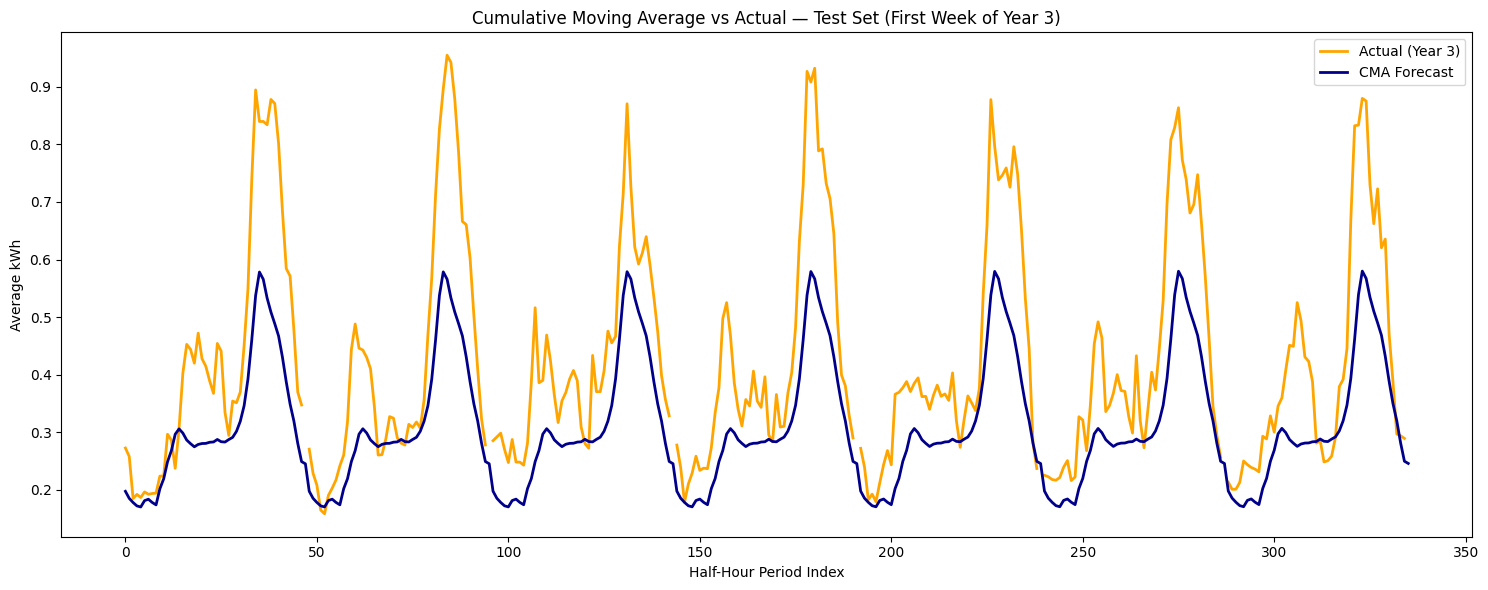

In [25]:
# ── Cumulative Moving Average (Train/Test Split) ──────────────────
# CMA is expanding mean — initialize on train, roll into test

df_long['CMA_Deseasonalized'] = df_long['Deseasonalized_kWh'].expanding().mean()
df_long['CMA'] = df_long['CMA_Deseasonalized'] * df_long['Seasonal_Index']

# Pull out test portion
test_cma = df_long[df_long['Date'] >= split_date].copy()

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_cma['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_cma['CMA'].values[:336],     label='CMA Forecast', color='darkblue', linewidth=2)
plt.title('Cumulative Moving Average vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# ── CMA Accuracy (Test Set Only) ─────────────────────────────────

test_cma_clean = test_cma.dropna(subset=['CMA', 'Avg_kWh'])
errors_cma = test_cma_clean['Avg_kWh'] - test_cma_clean['CMA']

Bias_cma  = errors_cma.mean()
MAD_cma   = errors_cma.abs().mean()
MAPE_cma  = (errors_cma.abs() / test_cma_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_cma  = np.sqrt((errors_cma ** 2).mean())
TS_cma    = Bias_cma / MAD_cma

print("=== Cumulative Moving Average — Test Set Accuracy ===")
print(f"  Bias : {Bias_cma:.4f} kWh")
print(f"  MAD  : {MAD_cma:.4f} kWh")
print(f"  MAPE : {MAPE_cma:.2f}%")
print(f"  RMSE : {RMSE_cma:.4f} kWh")
print(f"  TS   : {TS_cma:.4f}")

=== Cumulative Moving Average — Test Set Accuracy ===
  Bias : -0.0097 kWh
  MAD  : 0.0760 kWh
  MAPE : 25.65%
  RMSE : 0.1056 kWh
  TS   : -0.1274


## **Exponential Moving Average**

Optimal Alpha: 0.9900


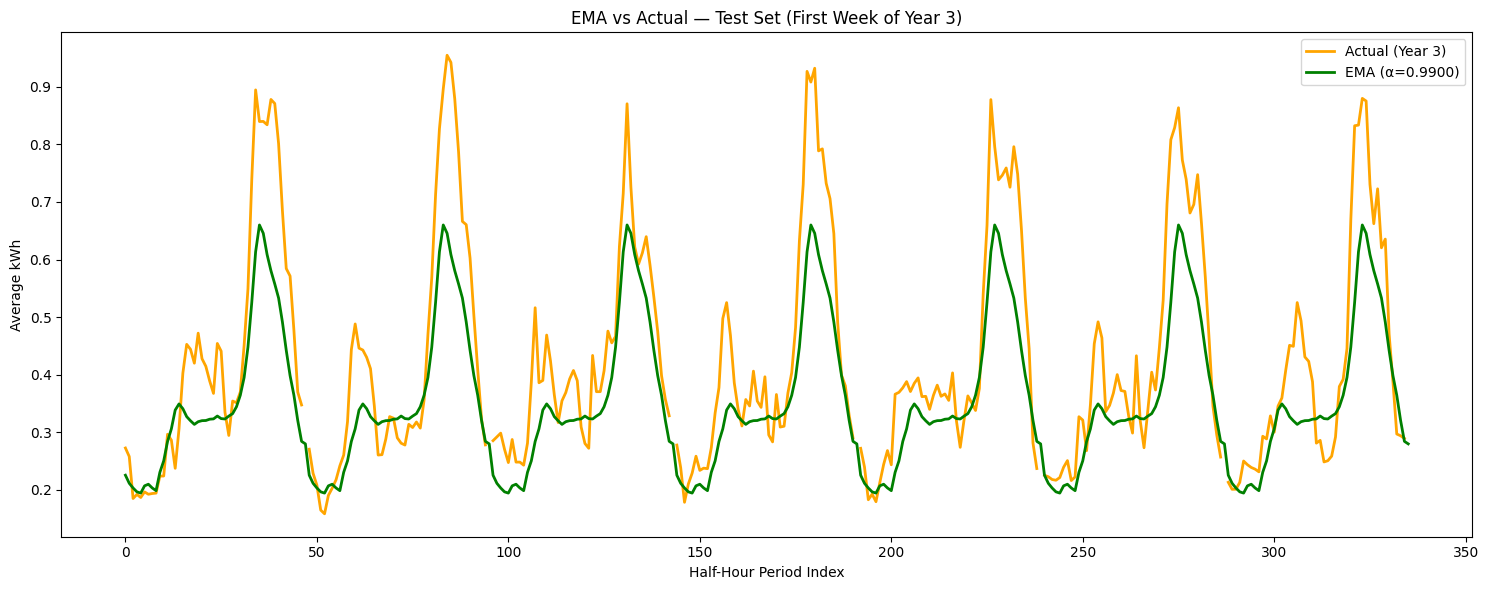

In [50]:
# ── EMA (Train/Test Split) ─────────────────────────────────

train_ema = df_long[df_long['Date'] < split_date].copy().reset_index(drop=True)
test_ema  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

# Find optimal alpha on train only
def ema_rmse(alpha):
    ema = train_ema['Deseasonalized_kWh'].ewm(alpha=alpha, adjust=False).mean()
    ema_reseason = ema * train_ema['Seasonal_Index']
    errors = train_ema['Avg_kWh'] - ema_reseason
    return np.sqrt((errors ** 2).mean())

from scipy.optimize import minimize_scalar
result = minimize_scalar(ema_rmse, bounds=(0.01, 0.99), method='bounded')
best_alpha = result.x
print(f"Optimal Alpha: {best_alpha:.4f}")

# Get last value from train to use as starting point
last_train_value = train_ema['Deseasonalized_kWh'].dropna().ewm(alpha=best_alpha, adjust=False).mean().iloc[-1]

# Forecast: EMA on test using only the last train value as init
ema_values = []
current = last_train_value
for val in test_ema['Deseasonalized_kWh']:
    current = best_alpha * current + (1 - best_alpha) * current  # flat forecast
    ema_values.append(current)

test_ema['EMA_best_Deseasonalized'] = ema_values
test_ema['EMA_best'] = test_ema['EMA_best_Deseasonalized'] * test_ema['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_ema['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_ema['EMA_best'].values[:336], label=f'EMA (α={best_alpha:.4f})', color='green', linewidth=2)
plt.title('EMA vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# ── EMA Accuracy (Test Set Only) ─────────────────────────────────

test_ema_clean = test_ema.dropna(subset=['EMA_best', 'Avg_kWh'])
errors_ema = test_ema_clean['Avg_kWh'] - test_ema_clean['EMA_best']

Bias_ema  = errors_ema.mean()
MAD_ema   = errors_ema.abs().mean()
MAPE_ema  = (errors_ema.abs() / test_ema_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_ema  = np.sqrt((errors_ema ** 2).mean())
TS_ema    = Bias_ema / MAD_ema

print(f"=== EMA (α={best_alpha:.4f}) Fixed — Test Set Accuracy ===")
print(f"  Bias : {Bias_ema:.4f} kWh")
print(f"  MAD  : {MAD_ema:.4f} kWh")
print(f"  MAPE : {MAPE_ema:.2f}%")
print(f"  RMSE : {RMSE_ema:.4f} kWh")
print(f"  TS   : {TS_ema:.4f}")

=== EMA (α=0.9900) Fixed — Test Set Accuracy ===
  Bias : -0.0542 kWh
  MAD  : 0.0955 kWh
  MAPE : 35.75%
  RMSE : 0.1198 kWh
  TS   : -0.5677


## **Simple Exponential Smoothing**

Optimal Alpha (SES): 0.9327


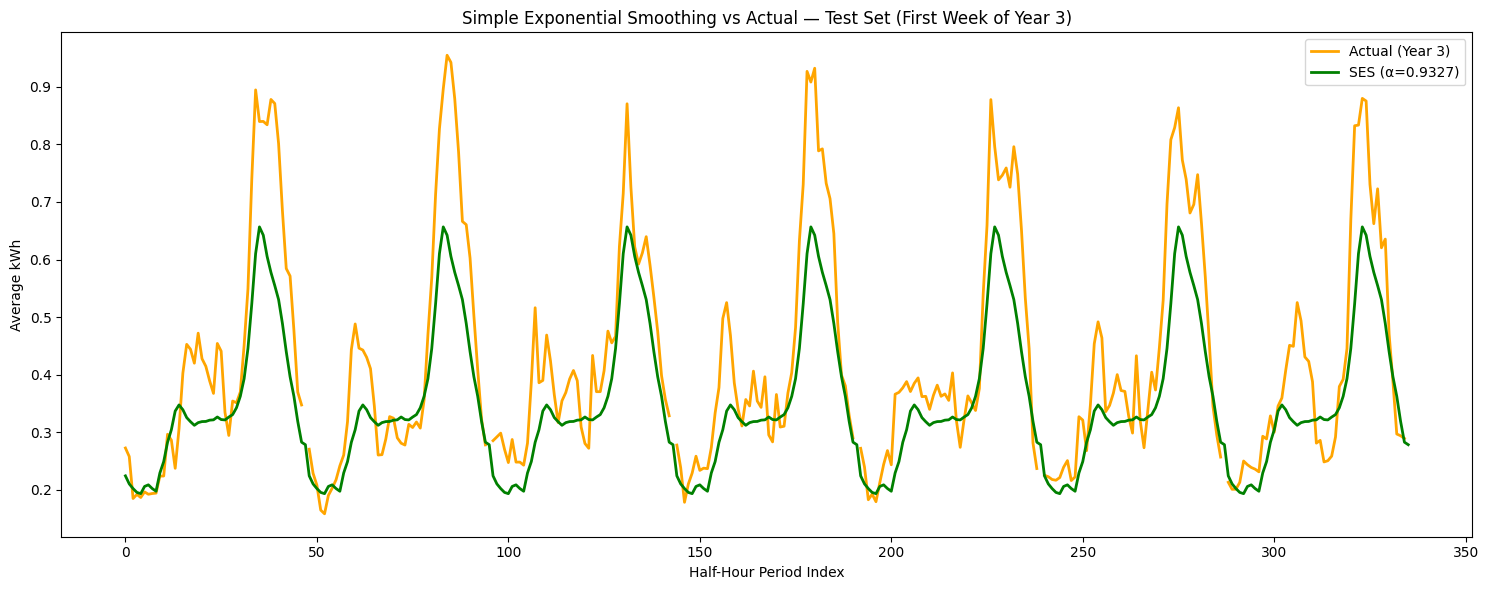

In [36]:
# ── Simple Exponential Smoothing (Train/Test Split) ───────────────

train_ses = df_long[df_long['Date'] < split_date]['Deseasonalized_kWh'].dropna().reset_index(drop=True)
test_ses  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

# Fit SES on train only
ses_model = SimpleExpSmoothing(train_ses).fit(optimized=True)
best_alpha_ses = ses_model.params['smoothing_level']
print(f"Optimal Alpha (SES): {best_alpha_ses:.4f}")

# Forecast and reset index to align with test_ses
ses_forecast = ses_model.forecast(len(test_ses)).reset_index(drop=True)

# Re-seasonalize
test_ses['SES_Deseasonalized'] = ses_forecast.values
test_ses['SES'] = test_ses['SES_Deseasonalized'] * test_ses['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_ses['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_ses['SES'].values[:336],     label=f'SES (α={best_alpha_ses:.4f})', color='green', linewidth=2)
plt.title('Simple Exponential Smoothing vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# ── SES Accuracy (Test Set Only) ─────────────────────────────────

test_ses_clean = test_ses.dropna(subset=['SES', 'Avg_kWh'])
errors_ses = test_ses_clean['Avg_kWh'] - test_ses_clean['SES']

Bias_ses  = errors_ses.mean()
MAD_ses   = errors_ses.abs().mean()
MAPE_ses  = (errors_ses.abs() / test_ses_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_ses  = np.sqrt((errors_ses ** 2).mean())
TS_ses    = Bias_ses / MAD_ses

print(f"=== Simple Exponential Smoothing (α={best_alpha_ses:.4f}) — Test Set Accuracy ===")
print(f"  Bias : {Bias_ses:.4f} kWh")
print(f"  MAD  : {MAD_ses:.4f} kWh")
print(f"  MAPE : {MAPE_ses:.2f}%")
print(f"  RMSE : {RMSE_ses:.4f} kWh")
print(f"  TS   : {TS_ses:.4f}")

=== Simple Exponential Smoothing (α=0.9327) — Test Set Accuracy ===
  Bias : -0.0524 kWh
  MAD  : 0.0945 kWh
  MAPE : 35.28%
  RMSE : 0.1189 kWh
  TS   : -0.5546


## **Double Holt Winters**

Alpha (level)  : 1.0000
Beta  (trend)  : 0.0000


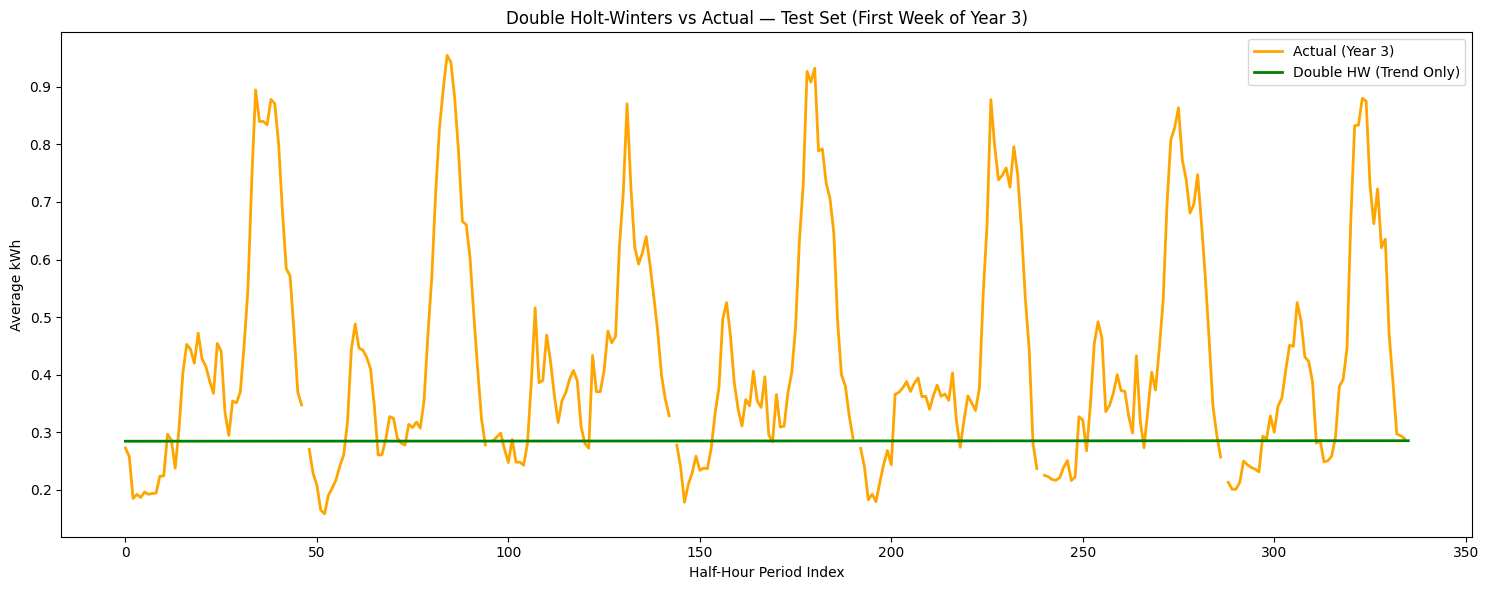

In [38]:
# ── Double Holt-Winters / Holt's Linear (Train/Test Split) ────────

train_hw2 = df_long[df_long['Date'] < split_date]['Avg_kWh'].dropna().reset_index(drop=True)
test_hw2  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

# Fit on train only
hw2_model = ExponentialSmoothing(train_hw2, trend='add').fit(optimized=True)

print(f"Alpha (level)  : {hw2_model.params['smoothing_level']:.4f}")
print(f"Beta  (trend)  : {hw2_model.params['smoothing_trend']:.4f}")

# Forecast forward into test period
hw2_forecast = hw2_model.forecast(len(test_hw2)).reset_index(drop=True)

test_hw2['HWES2_ADD'] = hw2_forecast.values

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_hw2['Avg_kWh'].values[:336], label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_hw2['HWES2_ADD'].values[:336], label='Double HW (Trend Only)', color='green', linewidth=2)
plt.title('Double Holt-Winters vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# ── Double HW Accuracy (Test Set Only) ───────────────────────────

test_hw2_clean = test_hw2.dropna(subset=['HWES2_ADD', 'Avg_kWh'])
errors_hw2 = test_hw2_clean['Avg_kWh'] - test_hw2_clean['HWES2_ADD']

Bias_hw2  = errors_hw2.mean()
MAD_hw2   = errors_hw2.abs().mean()
MAPE_hw2  = (errors_hw2.abs() / test_hw2_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_hw2  = np.sqrt((errors_hw2 ** 2).mean())
TS_hw2    = Bias_hw2 / MAD_hw2

print(f"=== Double Holt-Winters (Trend Only) — Test Set Accuracy ===")
print(f"  Bias : {Bias_hw2:.4f} kWh")
print(f"  MAD  : {MAD_hw2:.4f} kWh")
print(f"  MAPE : {MAPE_hw2:.2f}%")
print(f"  RMSE : {RMSE_hw2:.4f} kWh")
print(f"  TS   : {TS_hw2:.4f}")

=== Double Holt-Winters (Trend Only) — Test Set Accuracy ===
  Bias : -0.0052 kWh
  MAD  : 0.1148 kWh
  MAPE : 44.45%
  RMSE : 0.1530 kWh
  TS   : -0.0453


## **Triple Holt Winters**

Alpha (level)   : 0.8845
Beta  (trend)   : 0.0000
Gamma (seasonal): 0.1155


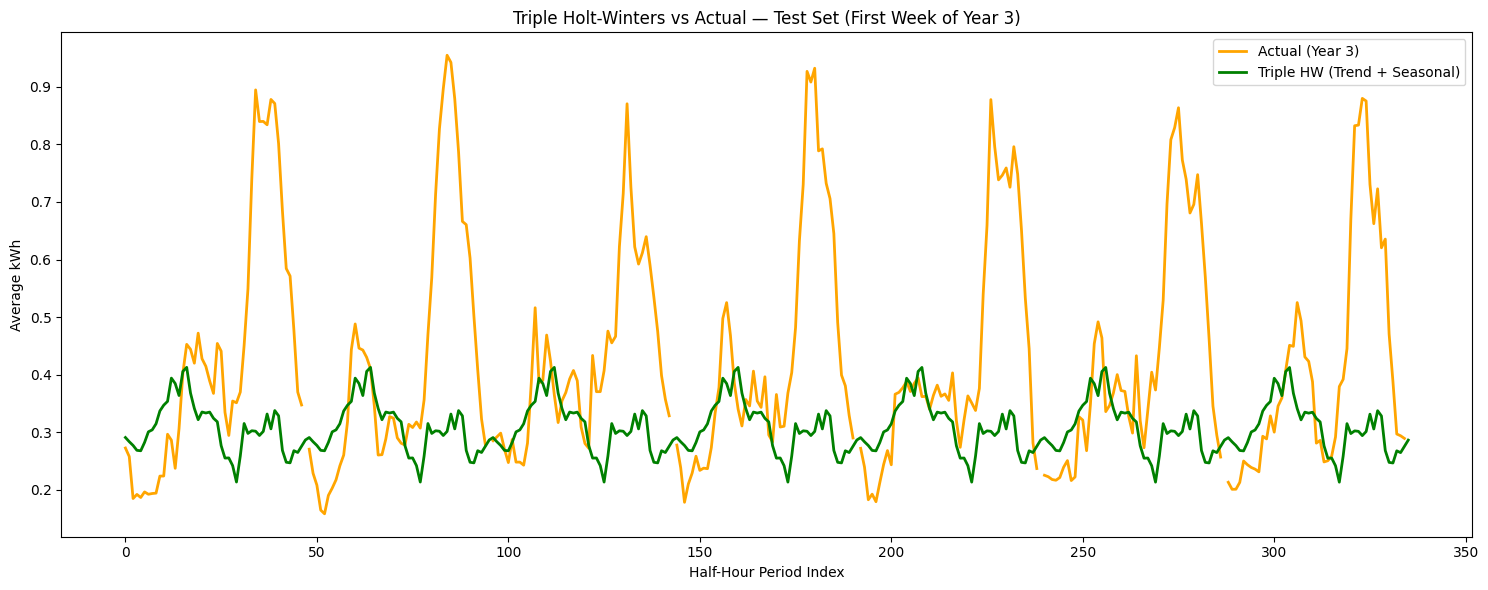

In [40]:
# ── Triple Holt-Winters (Train/Test Split) ────────────────────────
# seasonal_periods=48 (one full day of 30-min intervals)

train_hw3 = df_long[df_long['Date'] < split_date]['Avg_kWh'].dropna().reset_index(drop=True)
test_hw3  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

# Fit on train only
hw3_model = ExponentialSmoothing(
    train_hw3,
    trend='add',
    seasonal='add',
    seasonal_periods=48
).fit(optimized=True)

print(f"Alpha (level)   : {hw3_model.params['smoothing_level']:.4f}")
print(f"Beta  (trend)   : {hw3_model.params['smoothing_trend']:.4f}")
print(f"Gamma (seasonal): {hw3_model.params['smoothing_seasonal']:.4f}")

# Forecast forward into test period
hw3_forecast = hw3_model.forecast(len(test_hw3)).reset_index(drop=True)
test_hw3['HWES3_ADD'] = hw3_forecast.values

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_hw3['Avg_kWh'].values[:336],   label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_hw3['HWES3_ADD'].values[:336], label='Triple HW (Trend + Seasonal)', color='green', linewidth=2)
plt.title('Triple Holt-Winters vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# ── Triple HW Accuracy (Test Set Only) ───────────────────────────

test_hw3_clean = test_hw3.dropna(subset=['HWES3_ADD', 'Avg_kWh'])
errors_hw3 = test_hw3_clean['Avg_kWh'] - test_hw3_clean['HWES3_ADD']

Bias_hw3  = errors_hw3.mean()
MAD_hw3   = errors_hw3.abs().mean()
MAPE_hw3  = (errors_hw3.abs() / test_hw3_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_hw3  = np.sqrt((errors_hw3 ** 2).mean())
TS_hw3    = Bias_hw3 / MAD_hw3

print(f"=== Triple Holt-Winters (Trend + Seasonal) — Test Set Accuracy ===")
print(f"  Bias : {Bias_hw3:.4f} kWh")
print(f"  MAD  : {MAD_hw3:.4f} kWh")
print(f"  MAPE : {MAPE_hw3:.2f}%")
print(f"  RMSE : {RMSE_hw3:.4f} kWh")
print(f"  TS   : {TS_hw3:.4f}")

=== Triple Holt-Winters (Trend + Seasonal) — Test Set Accuracy ===
  Bias : 0.0015 kWh
  MAD  : 0.1180 kWh
  MAPE : 43.97%
  RMSE : 0.1567 kWh
  TS   : 0.0131


## **Linear Regression**

In [43]:
# ── Linear Regression (Train/Test Split) ─────────────────────────

train_lr = df_long[df_long['Date'] < split_date].copy().reset_index(drop=True)
test_lr  = df_long[df_long['Date'] >= split_date].copy().reset_index(drop=True)

# Build features for train
train_lr['t'] = np.arange(len(train_lr))
period_dummies_train = pd.get_dummies(train_lr['Period'], prefix='P', drop_first=True).astype(float)
X_train = pd.concat([train_lr[['t']], period_dummies_train], axis=1).astype(float)
X_train = sm.add_constant(X_train)
y_train = train_lr['Deseasonalized_kWh'].astype(float)

# Drop NaNs before fitting
mask = y_train.notna()
X_train = X_train[mask].reset_index(drop=True)
y_train = y_train[mask].reset_index(drop=True)

# Fit on train only
model_lr = sm.OLS(y_train, X_train).fit()


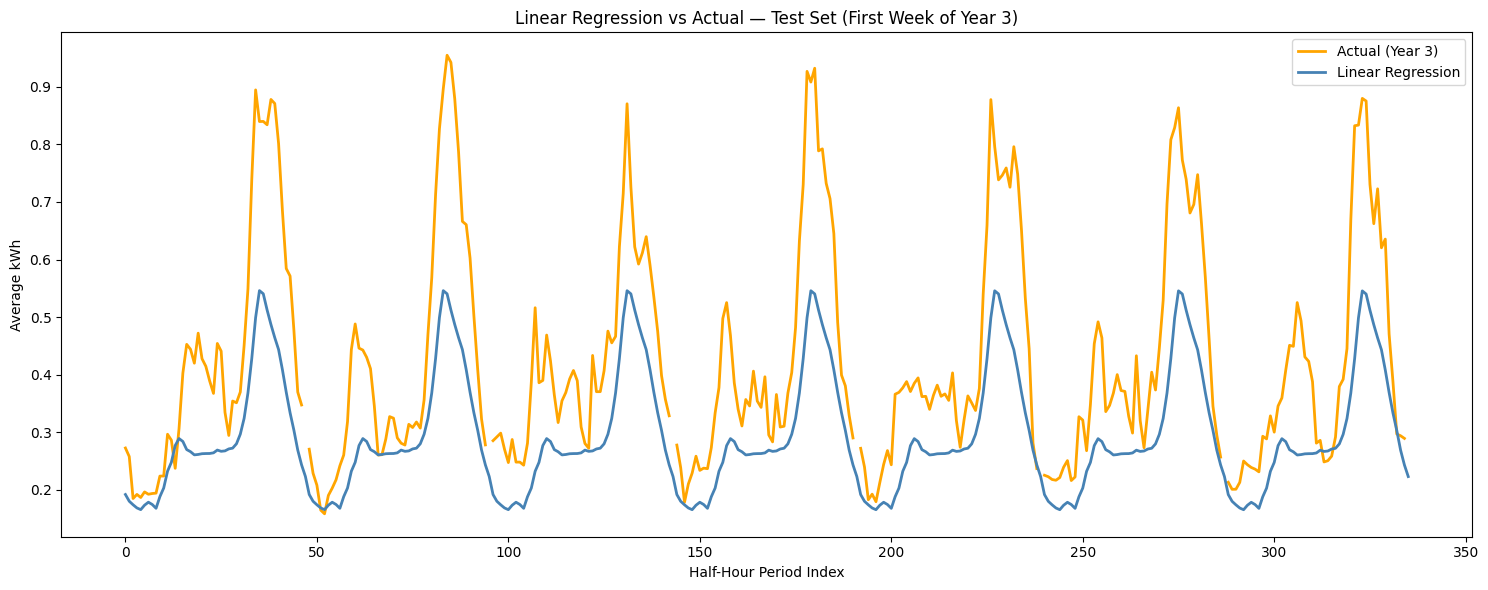

In [44]:
# ── Forecast on Test Set ──────────────────────────────────────────

# Build features for test (t continues from where train left off)
test_lr['t'] = np.arange(len(train_lr), len(train_lr) + len(test_lr))
period_dummies_test = pd.get_dummies(test_lr['Period'], prefix='P', drop_first=True).astype(float)
X_test = pd.concat([test_lr[['t']], period_dummies_test], axis=1).astype(float)
X_test = sm.add_constant(X_test)

# Predict and re-seasonalize
test_lr['LR_Deseasonalized'] = model_lr.predict(X_test)
test_lr['LR'] = test_lr['LR_Deseasonalized'] * test_lr['Seasonal_Index']

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test_lr['Avg_kWh'].values[:336],  label='Actual (Year 3)', color='orange', linewidth=2)
plt.plot(test_lr['LR'].values[:336],       label='Linear Regression', color='steelblue', linewidth=2)
plt.title('Linear Regression vs Actual — Test Set (First Week of Year 3)')
plt.xlabel('Half-Hour Period Index')
plt.ylabel('Average kWh')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# ── Linear Regression Accuracy (Test Set Only) ───────────────────

test_lr_clean = test_lr.dropna(subset=['LR', 'Avg_kWh'])
errors_lr = test_lr_clean['Avg_kWh'] - test_lr_clean['LR']

Bias_lr  = errors_lr.mean()
MAD_lr   = errors_lr.abs().mean()
MAPE_lr  = (errors_lr.abs() / test_lr_clean['Avg_kWh'].replace(0, np.nan)).mean() * 100
RMSE_lr  = np.sqrt((errors_lr ** 2).mean())
TS_lr    = Bias_lr / MAD_lr

print("=== Linear Regression — Test Set Accuracy ===")
print(f"  Bias : {Bias_lr:.4f} kWh")
print(f"  MAD  : {MAD_lr:.4f} kWh")
print(f"  MAPE : {MAPE_lr:.2f}%")
print(f"  RMSE : {RMSE_lr:.4f} kWh")
print(f"  TS   : {TS_lr:.4f}")

=== Linear Regression — Test Set Accuracy ===
  Bias : 0.0145 kWh
  MAD  : 0.0707 kWh
  MAPE : 21.96%
  RMSE : 0.1064 kWh
  TS   : 0.2048
